# dupOri cutter: hysteresis and toggling between plasmid-dominant states

Two incompatible plasmids — **A** (green) and **B** (red) — share a cell,
each replicating logistically against a common copy-number capacity of 30.
Each plasmid encodes a nuclease that degrades the other:

- **X** (encoded by A, amplified 50× by inducer **u1**) cuts **B**
- **Y** (encoded by B, amplified 50× by inducer **u2**) cuts **A**

At basal levels the nucleases are slow relative to replication (α = 50 vs
k = 0.01), so whichever plasmid wins even a small competition advantage
drives the other toward a low, stable copy number — **bistability**. Adding
u1 flips the system to an A-dominant state; removing u1 leaves it there
(**memory**). Adding u2 then flips it back toward B-dominance; removing u2
locks that in too. This notebook runs the full induction cycle:

> **equilibrate → +u1 → no inducer (memory) → +u2 → no inducer (memory)**

mirroring the toggle-switch protocol. A single non-growing cell is used
for the time-series and phase-plane plots (which cleanly resolve the
stochastic toggle); a growing colony drives the animation showing the
u1-induced flip and memory in a spatial context.


In [40]:
import os
import tempfile

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from IPython.display import Image

from multicellular import Cell, Colony, Environment, Field, ReactionNetwork, Simulation, visualize
from multicellular.core.reactions import Reaction

plt.rcParams["figure.dpi"] = 100


In [41]:
# Plasmid replication: logistic with shared copy-number capacity (30 total)
replication_A = Reaction(
    reactants={"A": 1, "B": 1}, products={"A": 2, "B": 1},
    rate_law_type="custom", rate_params={"alpha": 50},
    custom_rate_law=lambda rc, pc, cc, p:
        p["alpha"] * rc["A"] * (1 - (rc["A"] + rc["B"]) / 30),
)
replication_B = Reaction(
    reactants={"A": 1, "B": 1}, products={"A": 1, "B": 2},
    rate_law_type="custom", rate_params={"alpha": 50},
    custom_rate_law=lambda rc, pc, cc, p:
        p["alpha"] * rc["B"] * (1 - (rc["A"] + rc["B"]) / 30),
)

# X is produced by A-encoded genes (first catalyst = A for gene-dosage effect)
# and amplified 50-fold by inducer u1 via hill_langmuir.
x_production = Reaction(
    reactants={}, products={"X": 1},
    rate_law_type="hill_langmuir",
    rate_params={"alpha": 50, "beta": 1, "C": 1, "n": 2},
    catalysts=["A", "u1"],
)
# Y is produced by B-encoded genes, amplified by u2.
y_production = Reaction(
    reactants={}, products={"Y": 1},
    rate_law_type="hill_langmuir",
    rate_params={"alpha": 50, "beta": 1, "C": 1, "n": 2},
    catalysts=["B", "u2"],
)

# Cross-cutting: X degrades B; Y degrades A. Each nuclease acts as a catalyst
# (it is consumed and regenerated, net stoich = 0 for the nuclease).
A_degradation = Reaction(
    reactants={"A": 1, "Y": 1}, products={"Y": 1},
    rate_law_type="mass_action", rate_params={"k": 0.01},
)
B_degradation = Reaction(
    reactants={"B": 1, "X": 1}, products={"X": 1},
    rate_law_type="mass_action", rate_params={"k": 0.01},
)

# Nuclease proteolytic degradation — necessary for stable basal coexistence.
# Without it, constitutive X/Y production at rate ∝ A (or B) would accumulate
# and eliminate the competing plasmid even without any inducer.
x_degradation = Reaction(
    reactants={"X": 1}, products={},
    rate_law_type="mass_action", rate_params={"k": 30.0},
)
y_degradation = Reaction(
    reactants={"Y": 1}, products={},
    rate_law_type="mass_action", rate_params={"k": 30.0},
)

dupOri_cutter = ReactionNetwork(
    "dupOri_cutter",
    {
        "replication_A":  replication_A,
        "replication_B":  replication_B,
        "x_production":   x_production,
        "y_production":   y_production,
        "A_degradation":  A_degradation,
        "B_degradation":  B_degradation,
        "x_degradation":  x_degradation,
        "y_degradation":  y_degradation,
    },
    simulation_method="SSA"
)


## Environment and colony

The trap is **100 µm × 80 µm**. Inducers u1 and u2 are uniform chemical
fields; `colony.switch_environment()` swaps them in and out between phases.
The survival condition kills any cell whose A or B concentration drops
below 0.5 (less than ~1 plasmid copy). A and B are marked `low_copy=True`
for stochastic binomial partitioning at division.


In [42]:
# Trap dimensions: 100 µm × 80 µm → bounds = (x_width, y_height)
SHAPE  = (16, 20)          # rows × cols  (dy = 80/16 = 5 µm, dx = 100/20 = 5 µm)
BOUNDS = (100.0, 80.0)     # µm


def make_env(u1=0.0, u2=0.0):
    """Uniform-inducer environment for the 100 µm × 80 µm trap."""
    return Environment(
        shape=SHAPE, bounds=BOUNDS,
        fields=[
            Field("u1", np.full(SHAPE, u1), is_chemical=True),
            Field("u2", np.full(SHAPE, u2), is_chemical=True),
        ],
    )


# Seed two cells near the centre of the trap.
GROWTH_RATE = 0.04   # doubling time ≈ 17 time units
init_cells = [
    Cell(
        id=i, position=[46.0 + i * 8, 40.0], orientation=[1.0, 0.0], length=2.0,
        network=dupOri_cutter, growth_rate=GROWTH_RATE, rng=np.random.default_rng(i),
    )
    for i in range(2)
]
for cell in init_cells:
    cell.set_concentration("A", 10.0, low_copy=True)   # ~21 copies (vol ≈ 2.1 µm³)
    cell.set_concentration("B", 10.0, low_copy=True)

colony = Colony(
    init_cells, make_env(), k=10.0, drag=1.0,
    # Cell dies if it holds fewer than ~1 copy of either plasmid.
    survival_conditions=[("A", ">", 0.5), ("B", ">", 0.5)],
)


## Induction protocol

**Single non-growing cell** (for time series and phase plane):

| Phase | Duration | Inducer | Expected outcome |
|-------|----------|---------|-----------------|
| Equilibrate | 5 | — | A ≈ B |
| +u1 | 5 | u1 = 5 | A dominant, B low |
| no inducer | 5 | — | A-dominant **memory** |
| +u2 | 8 | u2 = 5 | A cut, B recovers to majority |
| no inducer | 5 | — | B-dominant **memory** |

`growth_rate=0` isolates the toggle from growth dilution, giving the
cleanest stochastic trajectory. A cloned network is used to keep the
single cell's SSA state independent of the colony simulation.

**Colony animation**: a single growing cell with ODE (deterministic) dynamics,
seeded with equal A and B. A 3-phase protocol shows both dominant states.
u1 is applied briefly so that B is still present (~7) when u2 is added —
Y production uses B as a catalyst, so some B must remain for the flip to succeed.

| Phase | Duration | Inducer | Expected outcome |
|-------|----------|---------|-----------------|
| Equilibrate | 5 | — | A ≈ B (yellow) |
| +u1 | 5 | u1 = 5 | A dominant, B ≈ 7 (green) |
| +u2 | 15 | u2 = 5 | B dominant (red) |

No survival condition is applied, so all cells remain alive through the full
colour transition.

In [43]:
DT = 0.02

# Induction phases for the single-cell toggle (t_end, u1, u2, label)
INDUCTION_PHASES = [
    (5.,  0, 0, "equilibrate\n(no inducer)"),
    (10., 5, 0, "+u1\n(X cuts B)"),
    (15., 0, 0, "no inducer\n(memory: A-high)"),
    (23., 0, 5, "+u2\n(Y cuts A)"),
    (28., 0, 0, "no inducer\n(memory: B-high)"),
]
PHASE_BOUNDARIES = [0.] + [t for t, *_ in INDUCTION_PHASES]

# ── Single non-growing cell (toggle demo) ───────────────────────────────────
# Clone the network so this cell's SSA state is fully independent of the
# colony cells defined above.
cell_single = Cell(
    id=0, position=[50.0, 40.0], orientation=[1.0, 0.0], length=2.0,
    network=dupOri_cutter.clone(), growth_rate=0.0, rng=np.random.default_rng(42),
)
cell_single.set_concentration("A", 15.0, low_copy=True)
cell_single.set_concentration("B", 15.0, low_copy=True)

colony_single = Colony(
    [cell_single], make_env(),
    survival_conditions=[("A", ">", 0.5), ("B", ">", 0.5)],
)
sim_single = Simulation(colony_single, dt=DT, t_max=INDUCTION_PHASES[0][0])
df_single = sim_single.run(show_progress=False)

for t_end, u1, u2, _ in INDUCTION_PHASES[1:]:
    colony_single.switch_environment(make_env(u1=u1, u2=u2))
    df_single = sim_single.run(t_max=t_end, show_progress=False)

per_single  = df_single[df_single["alive"]].groupby("time")[["A", "B"]].mean()
n_single    = df_single.groupby("time")["alive"].sum()

print("Single-cell toggle trajectory:")
for t_end, _, _, label in INDUCTION_PHASES:
    if t_end in per_single.index:
        print(f"  t={t_end:4.0f}  {label.splitlines()[0]:<28}"
              f"A={per_single.loc[t_end,'A']:.2f}  B={per_single.loc[t_end,'B']:.2f}")

# ── Colony animation: single growing cell, ODE dynamics ─────────────────────
# ODE gives deterministic, noise-free toggle dynamics. u1 is applied briefly
# (5 units) to establish A dominance while B is still non-zero (~7), then u2
# is applied. Y production uses B as a catalyst, so B must be present for the
# flip to B-dominant to succeed.
dupOri_cutter_ode = ReactionNetwork(
    "dupOri_cutter_ode",
    {k: v.clone() for k, v in dupOri_cutter.reactions.items()},
    simulation_method="ODE",
)

VID_PHASES = [
    (5.,  0, 0, "equilibrate"),
    (10., 5, 0, "+u1"),
    (25., 0, 5, "+u2"),
]

cell_vid = Cell(
    id=0, position=[50.0, 40.0], orientation=[1.0, 0.0], length=2.0,
    network=dupOri_cutter_ode, growth_rate=GROWTH_RATE, rng=np.random.default_rng(42),
)
cell_vid.set_concentration("A", 15.0)
cell_vid.set_concentration("B", 15.0)

colony_vid = Colony([cell_vid], make_env())
sim_vid = Simulation(colony_vid, dt=DT, t_max=VID_PHASES[0][0])
df_vid = sim_vid.run(show_progress=False)

for t_end, u1, u2, _ in VID_PHASES[1:]:
    colony_vid.switch_environment(make_env(u1=u1, u2=u2))
    df_vid = sim_vid.run(t_max=t_end, show_progress=False)

final_vid = df_vid[df_vid["time"] == df_vid["time"].max()]
print(f"\nColony (video) at t={df_vid.time.max():.0f}: "
      f"n={int(final_vid.alive.sum())}, "
      f"A={final_vid.A.mean():.2f}, B={final_vid.B.mean():.2f}")

Single-cell toggle trajectory:
  t=   5  equilibrate                 A=14.32  B=15.76
  t=  10  +u1                         A=22.92  B=7.16
  t=  15  no inducer                  A=22.44  B=7.64
  t=  23  +u2                         A=12.89  B=17.19
  t=  28  no inducer                  A=11.94  B=18.14

Colony (video) at t=25: n=4, A=8.97, B=20.95


## Time series: A and B concentrations through the induction cycle

Both plasmids start near equal copy numbers; the system drifts slightly
during equilibration (SSA noise) but stays close to 15:15. Adding u1
quickly drives A dominant while B drops. Removing u1 leaves A dominant
— **memory**. Adding u2 then tips A down and B up. Removing u2 freezes
that B-dominant state — **memory again**. The final state (B ≈ 18, A ≈ 12)
is different from both the starting state (15:15) and the intermediate
state (A ≈ 22, B ≈ 8), illustrating the path-dependent, hysteretic
character of the system.


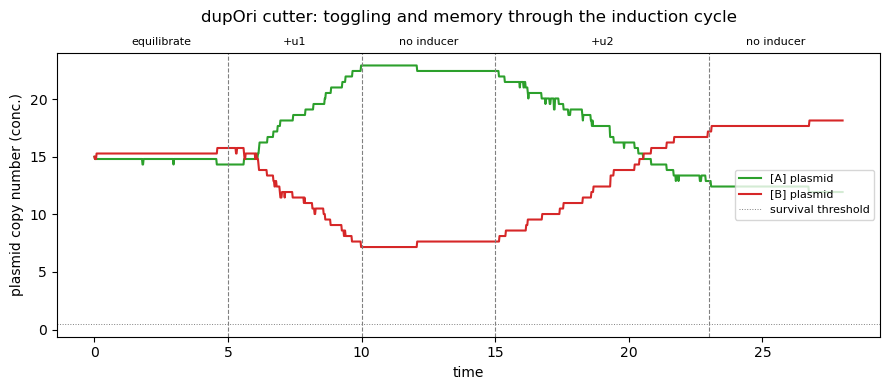

In [44]:
alive_df = df_single[df_single["alive"]]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(alive_df["time"], alive_df["A"], color="tab:green", label="[A] plasmid")
ax.plot(alive_df["time"], alive_df["B"], color="tab:red",   label="[B] plasmid")

# Phase boundary lines and labels (same pattern as toggle_switch_demo)
trans = ax.get_xaxis_transform()
for boundary in PHASE_BOUNDARIES[1:-1]:
    ax.axvline(boundary, color="gray", linestyle="--", linewidth=0.8)
for (t_end, _, _, label), t_start in zip(INDUCTION_PHASES, PHASE_BOUNDARIES[:-1]):
    ax.text(
        (t_start + t_end) / 2, 1.02, label.splitlines()[0],
        ha="center", va="bottom", fontsize=8, transform=trans,
    )

ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.7, label="survival threshold")
ax.set_xlabel("time")
ax.set_ylabel("plasmid copy number (conc.)")
ax.set_title("dupOri cutter: toggling and memory through the induction cycle", pad=22)
ax.legend(loc="center right", fontsize=8)
fig.tight_layout()
plt.show()


## Phase-plane trajectory: the hysteresis loop

In `(A, B)` space the hysteresis is geometric: the two "no inducer" phases
(purple and yellow) land at **different corners** even though both have
identical environments. The inducer history — not the current inducer level
— determines where the system sits. The trajectory traces a loop that cannot
be traversed in reverse without an opposite induction event.


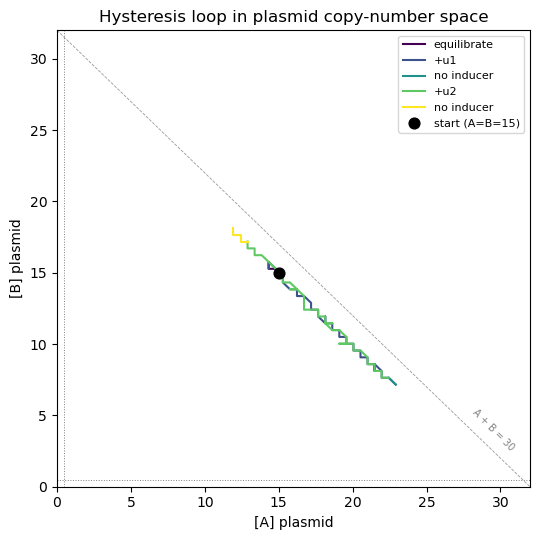

In [45]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(INDUCTION_PHASES)))

for (t_end, _, _, label), t_start, color in zip(
        INDUCTION_PHASES, PHASE_BOUNDARIES[:-1], colors):
    seg = alive_df[(alive_df["time"] >= t_start) & (alive_df["time"] <= t_end)]
    ax.plot(seg["A"], seg["B"], color=color, linewidth=1.5,
            label=label.splitlines()[0])

ax.scatter(alive_df["A"].iloc[0], alive_df["B"].iloc[0],
           color="black", zorder=5, s=60, label="start (A=B=15)")

lim = 32
ax.plot([0, lim], [lim, 0], "k--", linewidth=0.6, alpha=0.4)
ax.text(28, 2.5, "A + B = 30", fontsize=7, color="0.5", rotation=-45)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.7)
ax.axvline(0.5, color="gray", linestyle=":", linewidth=0.7)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("[A] plasmid"); ax.set_ylabel("[B] plasmid")
ax.set_title("Hysteresis loop in plasmid copy-number space")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()


## Colony animation: u1 → u2 induction

`visualize()` maps **plasmid A → green** and **plasmid B → red**. A single
growing cell is seeded with equal concentrations of A and B (yellow). ODE
dynamics give deterministic, noise-free toggle behaviour.

After a brief equilibration, **u1** is added: X production ramps up, degrading
B while A fills the logistic capacity — the colony turns **green**. Then **u2**
replaces u1: Y production degrades A while B rebounds — the colony turns **red**.
The colour transition yellow → green → red shows the system switching cleanly
between the two plasmid-dominant states.

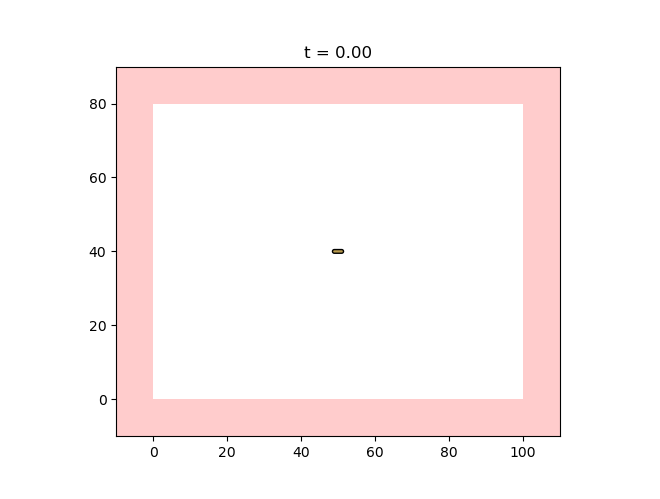

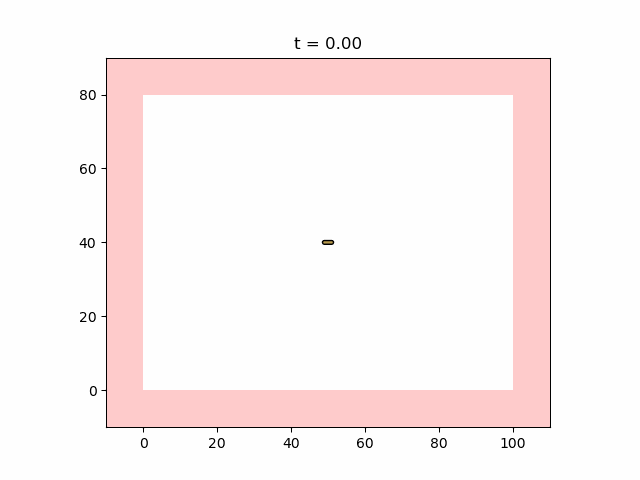

In [46]:
class _StrideView:
    def __init__(self, sim, stride):
        self._sim, self._stride, self.colony = sim, stride, sim.colony
    def to_dataframe(self):
        d = self._sim.to_dataframe()
        ts = sorted(d["time"].unique())[:: self._stride]
        return d[d["time"].isin(ts)]


output_dir = tempfile.mkdtemp()
visualize(
    _StrideView(sim_vid, stride=7),
    red="B", green="A",
    interval=100,
    save_path=output_dir,
    filename="dupOri_cutter.gif",
    show_progress=False,
)
Image(filename=os.path.join(output_dir, "dupOri_cutter.gif"))


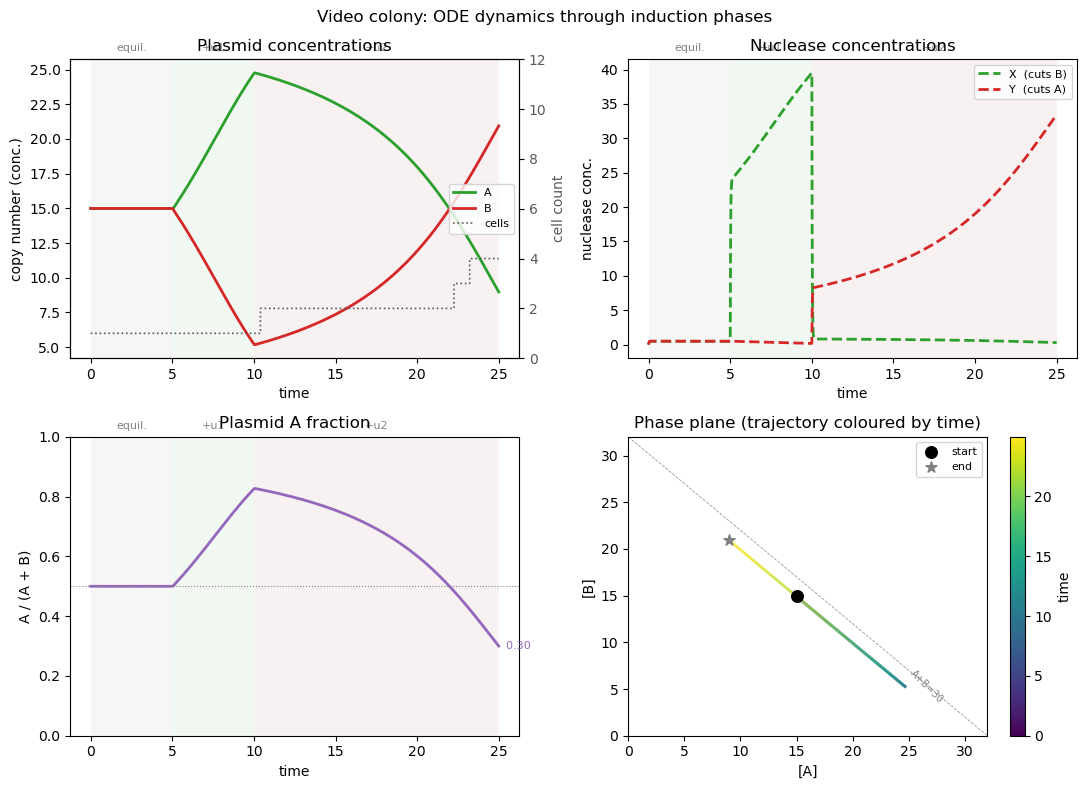

In [47]:
from matplotlib.collections import LineCollection

per_vid = df_vid.groupby("time")[["A", "B", "X", "Y"]].mean()
n_vid   = df_vid.groupby("time")["alive"].sum()
t       = per_vid.index.values

VID_PHASE_STARTS = [0.] + [ph[0] for ph in VID_PHASES]
_bg   = ["#f0f0f0", "#e6f4e6", "#f4e6e6"]
_lbls = ["equil.", "+u1", "+u2"]

def _shade(ax):
    tr = ax.get_xaxis_transform()
    for i, (t_end, *_) in enumerate(VID_PHASES):
        ax.axvspan(VID_PHASE_STARTS[i], t_end, color=_bg[i], alpha=0.55, lw=0, zorder=0)
        ax.text((VID_PHASE_STARTS[i] + t_end) / 2, 1.02, _lbls[i],
                ha="center", va="bottom", fontsize=8, color="0.5", transform=tr)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
fig.suptitle("Video colony: ODE dynamics through induction phases", fontsize=12)

# ── plasmid concentrations + cell count ──────────────────────────────────────
ax = axes[0, 0]
l1, = ax.plot(t, per_vid["A"], color="tab:green", lw=2, label="A")
l2, = ax.plot(t, per_vid["B"], color="tab:red",   lw=2, label="B")
_shade(ax)
ax.set_xlabel("time"); ax.set_ylabel("copy number (conc.)")
ax.set_title("Plasmid concentrations")
ax2r = ax.twinx()
l3, = ax2r.step(n_vid.index, n_vid.values, where="post",
                color="0.35", lw=1.2, linestyle=":", label="cells")
ax2r.set_ylabel("cell count", color="0.35")
ax2r.tick_params(axis="y", labelcolor="0.35")
ax2r.set_ylim(0, n_vid.max() * 3)
ax.legend(handles=[l1, l2, l3], fontsize=8, loc="center right")

# ── nuclease concentrations ───────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(t, per_vid["X"], color="tab:green", lw=2, linestyle="--", label="X  (cuts B)")
ax.plot(t, per_vid["Y"], color="tab:red",   lw=2, linestyle="--", label="Y  (cuts A)")
_shade(ax)
ax.set_xlabel("time"); ax.set_ylabel("nuclease conc.")
ax.set_title("Nuclease concentrations")
ax.legend(fontsize=8)

# ── A / (A+B) fraction ───────────────────────────────────────────────────────
ax = axes[1, 0]
ratio = per_vid["A"] / (per_vid["A"] + per_vid["B"])
ax.plot(t, ratio, color="tab:purple", lw=2)
ax.axhline(0.5, color="gray", linestyle=":", lw=0.8)
ax.set_ylim(0, 1)
_shade(ax)
ax.set_xlabel("time"); ax.set_ylabel("A / (A + B)")
ax.set_title("Plasmid A fraction")
ax.text(t[-1], ratio.iloc[-1], f"  {ratio.iloc[-1]:.2f}",
        va="center", fontsize=8, color="tab:purple")

# ── phase plane coloured by time ─────────────────────────────────────────────
ax = axes[1, 1]
pts  = np.column_stack([per_vid["A"].values, per_vid["B"].values])
segs = np.stack([pts[:-1], pts[1:]], axis=1)
lc   = LineCollection(segs, cmap="viridis", lw=2)
lc.set_array(t[:-1])
ax.add_collection(lc)
fig.colorbar(lc, ax=ax, label="time")
ax.scatter(*pts[0],  color="k",   zorder=5, s=70, label="start")
ax.scatter(*pts[-1], color="0.5", zorder=5, s=70, marker="*", label="end")
lim = 32
ax.plot([0, lim], [lim, 0], "k--", lw=0.6, alpha=0.4)
ax.text(25, 3.5, "A+B=30", fontsize=7, color="0.5", rotation=-45)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("[A]"); ax.set_ylabel("[B]")
ax.set_title("Phase plane (trajectory coloured by time)")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()